In [11]:
import duckdb
from scipy.stats import chisquare
con = duckdb.connect()
con.sql("CREATE OR REPLACE TABLE players AS SELECT * FROM 'data/cookie_cats.csv'")

In [31]:
con.sql("""
  SELECT version, COUNT(*) AS n_players
  FROM players
  GROUP BY version
  """)

┌─────────┬───────────┐
│ version │ n_players │
│ varchar │   int64   │
├─────────┼───────────┤
│ gate_40 │     45489 │
│ gate_30 │     44700 │
└─────────┴───────────┘

In [32]:
con.sql("""SELECT userid AS user FROM players WHERE version = 'gate_40' AND sum_gamerounds <2 """)

┌────────────┐
│    user    │
│   int64    │
├────────────┤
│        483 │
│       2502 │
│       4076 │
│       4902 │
│       6156 │
│       7509 │
│       8801 │
│       9828 │
│       9849 │
│      10276 │
│        ·   │
│        ·   │
│        ·   │
│    9969675 │
│    9970608 │
│    9979148 │
│    9981794 │
│    9983936 │
│    9988600 │
│    9988650 │
│    9989991 │
│    9994647 │
│    9995246 │
└────────────┘
  4846 rows 
  (20 shown) 

In [33]:
con.sql("""SELECT version, COUNT(userid) FROM players GROUP by version
""") #How many players are in each version?

┌─────────┬───────────────┐
│ version │ count(userid) │
│ varchar │     int64     │
├─────────┼───────────────┤
│ gate_40 │         45489 │
│ gate_30 │         44700 │
└─────────┴───────────────┘

In [27]:
#Are there duplicate userids?
con.sql("""
  SELECT userid, COUNT(*) AS times_seen
  FROM players
  GROUP BY userid
  HAVING COUNT(*) > 1
  """)

┌────────┬────────────┐
│ userid │ times_seen │
│ int64  │   int64    │
└────────┴────────────┘
        0 rows       

In [30]:
con.sql("""
SELECT version, COUNT(*) FROM players
WHERE sum_gamerounds =0
GROUP BY version""")

┌─────────┬──────────────┐
│ version │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ gate_30 │         1937 │
│ gate_40 │         2057 │
└─────────┴──────────────┘

In [44]:
con.sql("""SELECT version, AVG(sum_gamerounds) AS avg_rounds, MEDIAN(sum_gamerounds) AS median_rounds, MAX(sum_gamerounds) AS max_round FROM players
GROUP BY version
""")

┌─────────┬───────────────────┬───────────────┬───────────┐
│ version │    avg_rounds     │ median_rounds │ max_round │
│ varchar │      double       │    double     │   int64   │
├─────────┼───────────────────┼───────────────┼───────────┤
│ gate_40 │ 51.29877552814966 │          16.0 │      2640 │
│ gate_30 │ 52.45626398210291 │          17.0 │     49854 │
└─────────┴───────────────────┴───────────────┴───────────┘

In [45]:
con.sql("""SELECT version, AVG(CAST(retention_1 AS INTEGER)) AS retention_1day, AVG(CAST(retention_7 AS INTEGER)) AS retention_7day FROM players GROUP BY version
""")

┌─────────┬─────────────────────┬─────────────────────┐
│ version │   retention_1day    │   retention_7day    │
│ varchar │       double        │       double        │
├─────────┼─────────────────────┼─────────────────────┤
│ gate_30 │  0.4481879194630872 │ 0.19020134228187918 │
│ gate_40 │ 0.44228274967574577 │ 0.18200004396667327 │
└─────────┴─────────────────────┴─────────────────────┘

In [ ]:
# Two important observations:
#  1. The average is about 3× the median. That means the data is right-skewed: most players play a little, and a few play a lot. That's why the median is the better "typical player" number here. It's also why you'll later use the
#     Mann-Whitney U test for engagement rather than a t-test.
#  2. 49,854 rounds in 14 days is not realistic. That's about 3,560 rounds a day, or roughly 150 an hour around the clock. It's almost certainly a data error or a bot. The next-highest player (gate_40's 2,640) is far below it.

In [46]:
#identify the player
con.sql("""
  SELECT *
  FROM players
  WHERE sum_gamerounds = 49854
  """)

┌─────────┬─────────┬────────────────┬─────────────┬─────────────┐
│ userid  │ version │ sum_gamerounds │ retention_1 │ retention_7 │
│  int64  │ varchar │     int64      │   boolean   │   boolean   │
├─────────┼─────────┼────────────────┼─────────────┼─────────────┤
│ 6390605 │ gate_30 │          49854 │ false       │ true        │
└─────────┴─────────┴────────────────┴─────────────┴─────────────┘

In [48]:
con.sql("""
  CREATE OR REPLACE TABLE players_clean AS
  SELECT *
  FROM players
  WHERE sum_gamerounds < 49854
  """)

In [49]:
con.sql("""
  SELECT version, COUNT(*) AS n_players, MAX(sum_gamerounds) AS max_rounds
  FROM players_clean
  GROUP BY version
  """)

┌─────────┬───────────┬────────────┐
│ version │ n_players │ max_rounds │
│ varchar │   int64   │   int64    │
├─────────┼───────────┼────────────┤
│ gate_30 │     44699 │       2961 │
│ gate_40 │     45489 │       2640 │
└─────────┴───────────┴────────────┘

In [50]:
#FROM players_clean
con.sql("""SELECT version, AVG(sum_gamerounds) AS avg_rounds, MEDIAN(sum_gamerounds) AS median_rounds, MAX(sum_gamerounds) AS max_round 
FROM players_clean
GROUP BY version
""")

┌─────────┬────────────────────┬───────────────┬───────────┐
│ version │     avg_rounds     │ median_rounds │ max_round │
│ varchar │       double       │    double     │   int64   │
├─────────┼────────────────────┼───────────────┼───────────┤
│ gate_30 │ 51.342110561757536 │          17.0 │      2961 │
│ gate_40 │  51.29877552814966 │          16.0 │      2640 │
└─────────┴────────────────────┴───────────────┴───────────┘

In [51]:
con.sql("""SELECT version, AVG(CAST(retention_1 AS INTEGER)) AS retention_1day, AVG(CAST(retention_7 AS INTEGER)) AS retention_7day 
FROM players_clean
GROUP BY version
""")

┌─────────┬─────────────────────┬─────────────────────┐
│ version │   retention_1day    │   retention_7day    │
│ varchar │       double        │       double        │
├─────────┼─────────────────────┼─────────────────────┤
│ gate_30 │  0.4481979462627799 │ 0.19018322557551623 │
│ gate_40 │ 0.44228274967574577 │ 0.18200004396667327 │
└─────────┴─────────────────────┴─────────────────────┘

In [59]:
from scipy.stats import chisquare
  
observed = [44699, 45489]          # players in gate_30, gate_40 (from players_clean)
total = sum(observed)
expected = [total / 2, total / 2]  # what a perfect 50/50 split would look like
  
result = chisquare(observed, f_exp=expected)
result 

Power_divergenceResult(statistic=np.float64(6.919989355568369), pvalue=np.float64(0.008523748341090839))

In [ ]:
#pvalue=0.008<0.05:the split is not consistent with a fair 50/50 randomization.

In [62]:
con.sql("""SELECT version, COUNT(*) FROM players_clean 
GROUP BY version
""")

┌─────────┬──────────────┐
│ version │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ gate_40 │        45489 │
│ gate_30 │        44699 │
└─────────┴──────────────┘

In [63]:
con.sql("""SELECT version, SUM(CAST(retention_7 AS INTEGER)) FROM players_clean
GROUP BY version
""")

┌─────────┬───────────────────────────────────┐
│ version │ sum(CAST(retention_7 AS INTEGER)) │
│ varchar │              int128               │
├─────────┼───────────────────────────────────┤
│ gate_40 │                              8279 │
│ gate_30 │                              8501 │
└─────────┴───────────────────────────────────┘

In [66]:
con.sql("""SELECT version,
         COUNT(*) AS n_players,
         SUM(CAST(retention_7 AS INTEGER)) AS retained_7
  FROM players_clean
  GROUP BY version
  ORDER BY version""")
#  The question: is 19.0% vs 18.2% a real difference, or could it be random chance?
#  - H₀ (null hypothesis): both versions have the same 7-day retention rate.
#  - H₁ (alternative): the rates are different.

┌─────────┬───────────┬────────────┐
│ version │ n_players │ retained_7 │
│ varchar │   int64   │   int128   │
├─────────┼───────────┼────────────┤
│ gate_30 │     44699 │       8501 │
│ gate_40 │     45489 │       8279 │
└─────────┴───────────┴────────────┘

In [67]:
from statsmodels.stats.proportion import proportions_ztest
retained = [8501, 8279]      # gate_30, gate_40: players retained after 7 days
players  = [44699, 45489]    # gate_30, gate_40: total players
z_stat, p_value = proportions_ztest(count=retained, nobs=players)
z_stat, p_value

(np.float64(3.1574100858819936), np.float64(0.001591773177399344))

In [ ]:
#p = 0.0016
#z = 3.16
#7-day retention: gate_30 19.0% vs gate_40 18.2% (−0.8 points). 
#Two-proportion z-test: z = 3.16, p = 0.0016 < 0.05, so the difference is statistically significant. 
#Moving the gate to level 40 is associated with lower 7-day retention.



In [68]:
con.sql("""SELECT version,
         COUNT(*) AS n_players,
         SUM(CAST(retention_1 AS INTEGER)) AS retained_1
  FROM players_clean
  GROUP BY version
  ORDER BY version""")

┌─────────┬───────────┬────────────┐
│ version │ n_players │ retained_1 │
│ varchar │   int64   │   int128   │
├─────────┼───────────┼────────────┤
│ gate_30 │     44699 │      20034 │
│ gate_40 │     45489 │      20119 │
└─────────┴───────────┴────────────┘

In [71]:
from statsmodels.stats.proportion import proportions_ztest
retained = [20034, 20119]    # gate_30, gate_40: players retained after 1 day
players  = [44699, 45489]    # gate_30, gate_40: total players
z_stat, p_value = proportions_ztest(count=retained, nobs=players)
z_stat, p_value

(np.float64(1.787103509763628), np.float64(0.0739207603418346))

In [70]:
from statsmodels.stats.proportion import confint_proportions_2indep
low, high = confint_proportions_2indep(8501, 44699, 8279, 45489)
print(f"95% CI for difference (gate_30 - gate_40): [{low:.4f}, {high:.4f}]")

95% CI for difference (gate_30 - gate_40): [0.0031, 0.0133]


In [85]:
import numpy as np #loads NumPy for fast random resampling and math.
df = con.sql("SELECT version, CAST(retention_7 AS INTEGER) AS ret7 FROM players_clean").df()
df.head()#converts the SQL result into a pandas DataFrame and .head() show the first 5 rows to check data is loaded correctly

,version,ret7
0,gate_30,0
1,gate_30,0
2,gate_40,0
3,gate_40,0
4,gate_40,1


In [86]:
#estimate how uncertain the retention difference is, by simulating the experiment thousands of times.

rng = np.random.default_rng(42)          # fixed seed so results are reproducible

g30 = df[df["version"] == "gate_30"]["ret7"].to_numpy()
g40 = df[df["version"] == "gate_40"]["ret7"].to_numpy()

n_boot = 10000                            # start small; raise to 10,000 once it works
diffs = []

for i in range(n_boot):
    s30 = rng.choice(g30, size=len(g30), replace=True)   # resample gate_30 players
    s40 = rng.choice(g40, size=len(g40), replace=True)   # BLANK 1: same for gate_40
    diffs.append(s30.mean()-s40.mean())                                    # BLANK 2: difference in retention rates (gate_30 minus gate_40)

diffs = np.array(diffs)
diffs[:5]

array([0.01418279, 0.00958756, 0.00658322, 0.00500715, 0.00407447])

In [87]:
low, high = np.percentile(diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI: [{low:.4f}, {high:.4f}]")
print(f"P(gate_30 better): {(diffs > 0).mean():.3f}")

Bootstrap 95% CI: [0.0032, 0.0134]
P(gate_30 better): 1.000


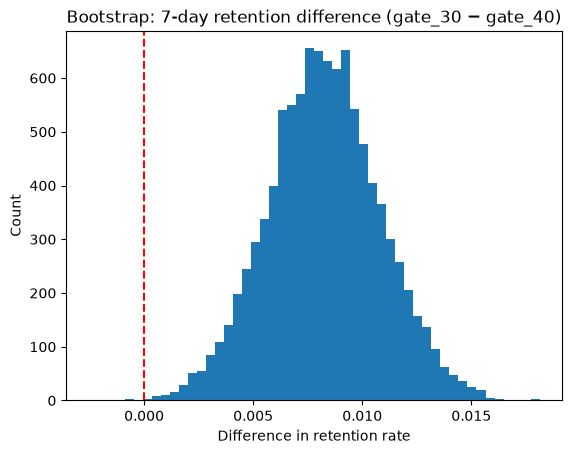

In [88]:
import matplotlib.pyplot as plt
plt.hist(diffs, bins=50) 
plt.axvline(0, color="red", linestyle="--")
plt.title("Bootstrap: 7-day retention difference (gate_30 − gate_40)")
plt.xlabel("Difference in retention rate")
plt.ylabel("Count")
plt.savefig("figures/bootstrap_7day.png", dpi=150, bbox_inches="tight")
plt.show()